<a href="https://colab.research.google.com/github/MrWaradana/bird-sound-classification/blob/main/Bird_Sound_Classification_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Required Libraries**

In [1]:
import os
import json
import cv2
import librosa
import IPython
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from warnings import filterwarnings

filterwarnings(action='ignore')

### **Data Collection**

In [2]:
# Download 'Sound Of 114 Species Of Birds Till 2022' dataset from Kaggle
# Dataset URL = https://www.kaggle.com/datasets/soumendraprasad/sound-of-114-species-of-birds-till-2022?select=Birds+Voice.csv

# !kaggle datasets download -d soumendraprasad/sound-of-114-species-of-birds-till-2022
import kagglehub
bird_path = kagglehub.dataset_download('soumendraprasad/sound-of-114-species-of-birds-till-2022')

100%|██████████| 2.06G/2.06G [00:24<00:00, 90.7MB/s]

Extracting files...


In [3]:
bird_path

'/root/.cache/kagglehub/datasets/soumendraprasad/sound-of-114-species-of-birds-till-2022/versions/1'

### **Sample Audio Checking**

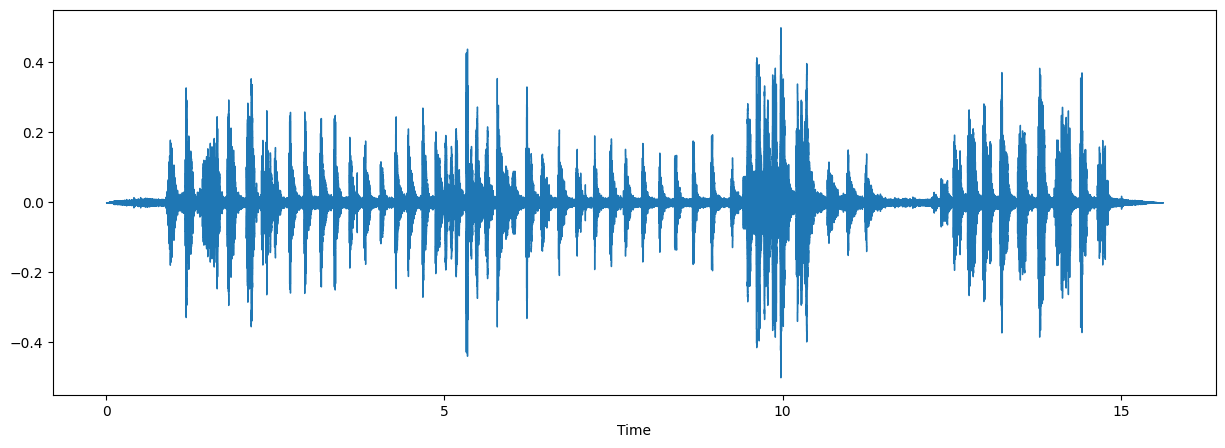

In [4]:
# Sample Audio Checking

# Set Plot Size
plt.figure(figsize=(15,5))

# Load Audio File to extract Audio Data and Sample Rate
audio_data, sample_rate = librosa.load(path=f'{bird_path}/Voice of Birds/Voice of Birds/Andean Guan_sound/Andean Guan12.mp3')
librosa.display.waveshow(y=audio_data, sr=sample_rate)

# View and Hear Audio File
IPython.display.Audio(data=f'{bird_path}/Voice of Birds/Voice of Birds/Andean Guan_sound/Andean Guan12.mp3')

In [5]:
# Audio will be automatically converted to Mono Channel [1-Dimentional Signal] Data
audio_data

array([ 8.6401997e-12, -1.2732926e-11, -1.8189894e-12, ...,
        2.2737368e-13,  3.9790393e-13, -8.5265128e-14], dtype=float32)

In [6]:
# Audio will be automatically resampled to the rate of 22050Hz (default sr=22050)
sample_rate

22050

**Mel-Frequency Cepstral Coefficients (MFCC)**

*MFCC help to extract the features from audio based on frequency and time charecteristics. This features will help in classification.*

- It summarize the frequency distribution across window size.

- So it analyse `frequency & time charecteristics` of the sound.

- This audio representations help to identify the features for classification.


In [7]:
# Sample Audio Checking
mfccs_features = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=40)

Default n_mfcc = 20 & we put n_mfcc = 40




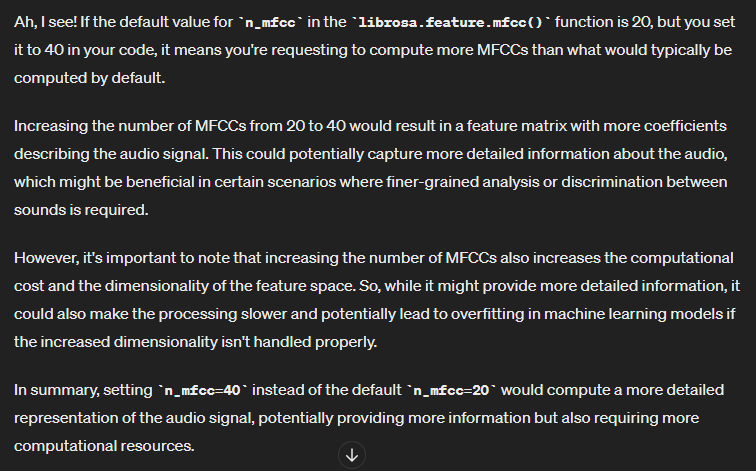

In [8]:
# Sample Audio Checking
mfccs_features, mfccs_features.shape

(array([[-6.2250488e+02, -6.0999121e+02, -5.7499744e+02, ...,
         -6.2250488e+02, -6.2250488e+02, -6.2250488e+02],
        [ 0.0000000e+00,  1.6979614e+01,  4.1984943e+01, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  1.5081097e+01,  2.0330696e+01, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        ...,
        [ 0.0000000e+00, -7.2472107e-01,  3.1355238e-01, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00, -9.6145791e-01, -1.4942675e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00, -1.1581572e+00, -1.6853914e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32),
 (40, 673))

which contains Mel-Frequency Cepstral Coefficients (MFCCs) computed from audio data.
The shape `(40, 673)` indicates that
- 40 rows (representing the 40 MFCC features)
- 673 columns (representing different frames or segments of the audio signal).

In [9]:
# Sample Audio Checking
np.mean(mfccs_features, axis=1)     # axis=1 means row wise mean calculation - shape=(40,0)  &  axis=0 means column wise mean caculation - shape=(673,)

array([-3.0988004e+02,  1.0401821e+01, -9.0290489e+01, -4.4553440e+01,
       -1.8831221e+01,  7.9951978e+00, -1.9813392e+00, -6.6336718e+00,
       -7.9205399e+00,  1.2260887e+01,  1.1192107e+01,  1.1200222e+01,
       -3.1864762e-01,  3.7352815e+00,  5.5541921e+00,  6.4173203e+00,
        4.7119589e+00,  9.6746712e+00, -4.9130853e-02,  4.7118936e+00,
        3.7892053e+00,  8.2409830e+00,  1.1635526e+00,  4.1349077e+00,
        9.1222793e-01,  2.1938603e+00, -1.7673434e+00,  3.5073230e+00,
       -4.5820805e-01,  2.3610866e+00, -5.3835887e-01,  2.1143441e+00,
       -2.3396833e+00,  2.3190193e+00, -1.8095652e+00,  1.0630903e+00,
       -2.8051739e+00, -1.6753897e-01, -1.6882221e+00,  1.8219043e+00],
      dtype=float32)

In [10]:
np.mean(mfccs_features, axis=1).shape

(40,)

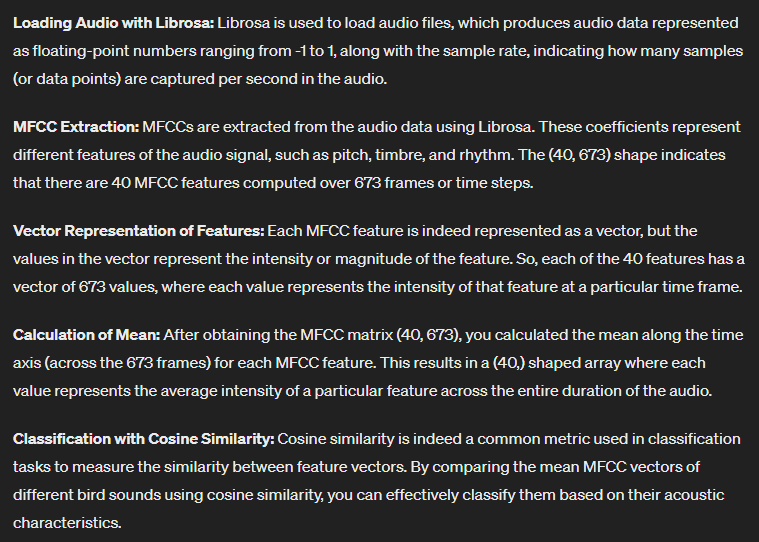

### **Data Preprocessing**

In [11]:
# Convert the mp3 Audio into Tensors

def audio_to_tensors(audio_file):
    # Extract the Signal and Sample_Rate from Audio
    audio, sample_rate =librosa.load(audio_file)

    # Extract the MFCC Features and Aggrigate
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_features = np.mean(mfccs_features, axis=1)

    # Convert into Tensors
    mfccs_tensors = tf.convert_to_tensor(mfccs_features, dtype=tf.float32)

    return mfccs_tensors

In [12]:
# Sample Audio
audio_sample = f'{bird_path}/Voice of Birds/Voice of Birds/Andean Guan_sound/Andean Guan10.mp3'
audio_to_tensors(audio_sample)

<tf.Tensor: shape=(40,), dtype=float32, numpy=
array([-302.73083   ,   70.47813   ,   13.989463  ,   28.275862  ,
          9.768283  ,    7.4185357 ,    3.663607  ,   12.622561  ,
          0.9152409 ,    3.15177   ,    4.5321455 ,    6.7180853 ,
         -2.076896  ,    5.5894322 ,    3.0978475 ,    1.8796209 ,
         -0.49635005,    6.4944406 ,    2.0897276 ,    4.146482  ,
          2.351528  ,    7.5341434 ,    0.63787776,    5.8428    ,
          4.5193014 ,    5.587803  ,    1.6145756 ,    6.687456  ,
          2.1035836 ,    4.2177606 ,    2.5508912 ,    4.631444  ,
          0.40562922,    4.092282  ,    1.5406473 ,    3.7211802 ,
          0.5173263 ,    3.6272905 ,    0.56133217,    3.1007855 ],
      dtype=float32)>

In [13]:
# Extract the Features from Audio Files

# Audio Directory Path
directory = f'{bird_path}/Voice of Birds/Voice of Birds'

extracted_features = []

# Count the total number of files
total_files = sum(len(files) for _, _, files in os.walk(directory))

# Initialize tqdm with the total number of files
with tqdm(total=total_files, desc='Processing files') as pbar:

  for target_class in os.listdir(directory):                               # List of All Target Folder Names in Directory

      target_class_path = os.path.join(directory, target_class)            # Make a Target Folder Path in Directory

      for audio_file in os.listdir(target_class_path):                     # List of All Audio Files in Target Folder

          audio_path = os.path.join(directory, target_class, audio_file)   # Make a Audio File Path from Target Folder in Directory

          features = audio_to_tensors(audio_path)                          # Extract the Features from the Audio File

          extracted_features.append([features, target_class])              # Append the Features and Target_Class in List

          pbar.update(1)                                                   # Update the progress bar for each file processed


Processing files: 100%|██████████| 2161/2161 [06:26<00:00,  5.58it/s]


In [14]:
extracted_features[0]

[<tf.Tensor: shape=(40,), dtype=float32, numpy=
 array([-1.4423149e+02,  5.9518269e+01, -9.2535324e+01, -5.1235573e+01,
        -5.0178764e+01, -2.2908089e+01, -3.4731056e+01, -1.5775664e+01,
        -2.6618181e+01, -1.5138870e+01, -2.0296473e+01, -1.3502557e+01,
        -1.9120020e+01, -1.0534525e+01, -1.6527561e+01, -9.7113733e+00,
        -1.2436582e+01, -8.3034220e+00, -1.0816885e+01, -3.8218348e+00,
        -8.6257715e+00, -2.0047839e+00, -6.0097666e+00, -2.2992396e+00,
        -4.7069192e+00, -9.4291198e-01, -4.8884234e+00,  1.0787879e-01,
        -4.0997844e+00, -7.8737035e-02, -3.5740283e+00, -9.7943807e-01,
        -3.3688715e+00,  1.2515803e-01, -2.9331641e+00,  9.9336100e-01,
        -2.2462907e+00,  2.0750115e+00, -1.6040653e+00,  2.1652563e+00],
       dtype=float32)>,
 'Southern Brown Kiwi_sound']

In [15]:
# Creating DataFrame from Extracted Features with Class Labels

features_df = pd.DataFrame(extracted_features, columns=['features', 'class'])
features_df

,features,class
0,"(tf.Tensor(-144.23149, shape=(), dtype=float32...",Southern Brown Kiwi_sound
1,"(tf.Tensor(-19.098063, shape=(), dtype=float32...",Southern Brown Kiwi_sound
2,"(tf.Tensor(-295.51523, shape=(), dtype=float32...",Southern Brown Kiwi_sound
3,"(tf.Tensor(-259.1743, shape=(), dtype=float32)...",Black-capped Tinamou_sound
4,"(tf.Tensor(-302.18384, shape=(), dtype=float32...",Black-capped Tinamou_sound
...,...,...
2156,"(tf.Tensor(-221.72859, shape=(), dtype=float32...",Andean Tinamou_sound
2157,"(tf.Tensor(-317.6797, shape=(), dtype=float32)...",Andean Tinamou_sound
2158,"(tf.Tensor(-229.69812, shape=(), dtype=float32...",Andean Tinamou_sound
2159,"(tf.Tensor(-205.65216, shape=(), dtype=float32...",Andean Tinamou_sound


In [16]:
# Encoding Class Labels using LabelEncoder

target_encoding = LabelEncoder().fit_transform(features_df['class'])
target_encoding

array([88, 88, 88, ...,  1,  1,  1])

In [17]:
# Adding Encoded Class Labels Column to DataFrame

features_df['target'] = target_encoding.tolist()
features_df

,features,class,target
0,"(tf.Tensor(-144.23149, shape=(), dtype=float32...",Southern Brown Kiwi_sound,88
1,"(tf.Tensor(-19.098063, shape=(), dtype=float32...",Southern Brown Kiwi_sound,88
2,"(tf.Tensor(-295.51523, shape=(), dtype=float32...",Southern Brown Kiwi_sound,88
3,"(tf.Tensor(-259.1743, shape=(), dtype=float32)...",Black-capped Tinamou_sound,12
4,"(tf.Tensor(-302.18384, shape=(), dtype=float32...",Black-capped Tinamou_sound,12
...,...,...,...
2156,"(tf.Tensor(-221.72859, shape=(), dtype=float32...",Andean Tinamou_sound,1
2157,"(tf.Tensor(-317.6797, shape=(), dtype=float32)...",Andean Tinamou_sound,1
2158,"(tf.Tensor(-229.69812, shape=(), dtype=float32...",Andean Tinamou_sound,1
2159,"(tf.Tensor(-205.65216, shape=(), dtype=float32...",Andean Tinamou_sound,1


In [18]:
# Creating a Dictionary based on Class and Target columns for Future Prediction

prediction_dict = features_df.set_index('target')['class'].to_dict()
prediction_dict

{88: 'Southern Brown Kiwi_sound',
 12: 'Black-capped Tinamou_sound',
 16: 'Brown Tinamou_sound',
 78: 'Rufous-bellied Chachalaca_sound',
 111: 'White-throated Tinamou_sound',
 28: 'Colombian Chachalaca_sound',
 65: 'Orange-footed Scrubfowl_sound',
 101: 'Trinidad Piping Guan_sound',
 52: 'Little Spotted Kiwi_sound',
 112: 'White-winged Guan_sound',
 4: 'Barred Tinamou_sound',
 50: 'Lesser Rhea_sound',
 15: 'Brazilian Tinamou_sound',
 48: 'Huayco Tinamou_sound',
 26: 'Cinereous Tinamou_sound',
 67: 'Pale-browed Tinamou_sound',
 0: 'Andean Guan_sound',
 7: 'Bearded Guan_sound',
 100: 'Tongan Megapode_sound',
 72: 'Quebracho Crested Tinamou_sound',
 18: 'Buff-browed Chachalaca_sound',
 75: 'Red-legged Tinamou_sound',
 31: 'Curve-billed Tinamou_sound',
 86: 'Solitary Tinamou_sound',
 68: 'Patagonian Tinamou_sound',
 25: 'Choco Tinamou_sound',
 37: 'East Brazilian Chachalaca_sound',
 20: 'Chaco Chachalaca_sound',
 23: 'Chestnut-winged Chachalaca_sound',
 87: 'Somali Ostrich_sound',
 53: 'Li

In [19]:
# Save to JSON File

with open(file=f'{bird_path}/prediction.json', mode='w') as f:
    json.dump(prediction_dict, f)

In [20]:
# Read the Prediction_Dictionary File

with open(file=f'{bird_path}/prediction.json', mode='r') as f:
    prediction_dict = json.load(f)
prediction_dict

{'88': 'Southern Brown Kiwi_sound',
 '12': 'Black-capped Tinamou_sound',
 '16': 'Brown Tinamou_sound',
 '78': 'Rufous-bellied Chachalaca_sound',
 '111': 'White-throated Tinamou_sound',
 '28': 'Colombian Chachalaca_sound',
 '65': 'Orange-footed Scrubfowl_sound',
 '101': 'Trinidad Piping Guan_sound',
 '52': 'Little Spotted Kiwi_sound',
 '112': 'White-winged Guan_sound',
 '4': 'Barred Tinamou_sound',
 '50': 'Lesser Rhea_sound',
 '15': 'Brazilian Tinamou_sound',
 '48': 'Huayco Tinamou_sound',
 '26': 'Cinereous Tinamou_sound',
 '67': 'Pale-browed Tinamou_sound',
 '0': 'Andean Guan_sound',
 '7': 'Bearded Guan_sound',
 '100': 'Tongan Megapode_sound',
 '72': 'Quebracho Crested Tinamou_sound',
 '18': 'Buff-browed Chachalaca_sound',
 '75': 'Red-legged Tinamou_sound',
 '31': 'Curve-billed Tinamou_sound',
 '86': 'Solitary Tinamou_sound',
 '68': 'Patagonian Tinamou_sound',
 '25': 'Choco Tinamou_sound',
 '37': 'East Brazilian Chachalaca_sound',
 '20': 'Chaco Chachalaca_sound',
 '23': 'Chestnut-winge

In [21]:
# Converting Features into List
features = features_df['features'].tolist()
features

[<tf.Tensor: shape=(40,), dtype=float32, numpy=
 array([-1.4423149e+02,  5.9518269e+01, -9.2535324e+01, -5.1235573e+01,
        -5.0178764e+01, -2.2908089e+01, -3.4731056e+01, -1.5775664e+01,
        -2.6618181e+01, -1.5138870e+01, -2.0296473e+01, -1.3502557e+01,
        -1.9120020e+01, -1.0534525e+01, -1.6527561e+01, -9.7113733e+00,
        -1.2436582e+01, -8.3034220e+00, -1.0816885e+01, -3.8218348e+00,
        -8.6257715e+00, -2.0047839e+00, -6.0097666e+00, -2.2992396e+00,
        -4.7069192e+00, -9.4291198e-01, -4.8884234e+00,  1.0787879e-01,
        -4.0997844e+00, -7.8737035e-02, -3.5740283e+00, -9.7943807e-01,
        -3.3688715e+00,  1.2515803e-01, -2.9331641e+00,  9.9336100e-01,
        -2.2462907e+00,  2.0750115e+00, -1.6040653e+00,  2.1652563e+00],
       dtype=float32)>,
 <tf.Tensor: shape=(40,), dtype=float32, numpy=
 array([-1.9098063e+01,  9.9265121e+01, -3.2237293e+01,  1.0451186e+01,
        -1.0897032e+01,  2.5508389e+00, -1.3665488e+01,  2.7909845e-01,
        -1.2076

In [22]:
# Converting Targets into Lists
target = features_df['target'].tolist()
print(target)

[88, 88, 88, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 111, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 65, 101, 52, 52, 52, 52, 52, 52, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 4, 4, 4, 50, 50, 50, 50, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,

In [23]:
# Converting Features and Targets to TensorFlow Tensors
features_tensor = tf.convert_to_tensor(features)
target_tensor = tf.convert_to_tensor(target)

In [24]:
features_tensor

<tf.Tensor: shape=(2161, 40), dtype=float32, numpy=
array([[-1.4423149e+02,  5.9518269e+01, -9.2535324e+01, ...,
         2.0750115e+00, -1.6040653e+00,  2.1652563e+00],
       [-1.9098063e+01,  9.9265121e+01, -3.2237293e+01, ...,
        -5.3605574e-01, -3.8132758e+00, -2.9415867e-01],
       [-2.9551523e+02,  1.2131812e+02,  5.7754234e+01, ...,
         1.5651055e-01, -9.2398727e-01,  7.5125527e-01],
       ...,
       [-2.2969812e+02,  8.5498665e+01, -6.6313324e+00, ...,
        -6.4148045e-01, -4.2834063e+00, -1.7355577e+00],
       [-2.0565216e+02,  4.7045296e+01,  5.5954784e-01, ...,
         3.0070913e+00, -6.6371256e-01,  3.0270057e+00],
       [-1.9320331e+02,  7.3176720e+01, -6.3861256e+00, ...,
         3.4131916e+00, -1.4883368e+00,  3.0948234e+00]], dtype=float32)>

In [25]:
target_tensor

<tf.Tensor: shape=(2161,), dtype=int32, numpy=array([88, 88, 88, ...,  1,  1,  1], dtype=int32)>

In [26]:
# Creating TensorFlow Dataset from Tensors
dataset = tf.data.Dataset.from_tensor_slices((features_tensor, target_tensor))
dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(40,), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

In [27]:
# Split the dataset into batches
batch_size = 32
dataset = dataset.batch(batch_size)
dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [28]:
# Length of Batched Bird Dataset
len(dataset)

68

In [29]:
# Maximum Number of Images Count
68*32

2176

In [30]:
# No of images in Last Badge
2176-2161

15

In [31]:
# Define a Function process to Split Dataset into Training(80%), Validation(10%) and Testing(10%) Sets

def train_validation_test_split(dataset, train_size=0.8, validation_size=0.1, test_size=0.1, shuffle=True, shuffle_size=10000):

    dataset_batch_count = len(dataset)                                                  # Batch Images dataset Length is 68
    train_batch_count = int(dataset_batch_count * train_size)                           # int(68*0.8) ---> 54 Batches are Training
    validation_test_batch_count = int(dataset_batch_count * validation_size)            # int(68*0.1) ---> 6 Batches are validation & Remaining Testing

    if shuffle:
        dataset = dataset.shuffle(buffer_size=shuffle_size)                             # Suffling the Dataset help to Model Understand the Data Well

    train_ds = dataset.take(train_batch_count)                                          # First 54 Batches are Training_Dataset
    validation_ds = dataset.skip(train_batch_count).take(validation_test_batch_count)   # Remaining 14 Batches ---> Next 6 Batch are Validation_Dataset
    test_ds = dataset.skip(train_batch_count).skip(validation_test_batch_count)         # Pending 8 Batches are Testing

    return train_ds, validation_ds, test_ds

In [32]:
# Apply the Function in Bird Dataset
train_ds, validation_ds, test_ds = train_validation_test_split(dataset)
len(train_ds), len(validation_ds), len(test_ds)

(54, 6, 8)

(40,)
[-267.6377       43.61686     -45.448906    -10.48535     -51.806442
  -18.057125    -33.914055    -41.420635    -16.298319    -19.781609
  -16.65243       1.6476594    -9.435884      4.8758955     3.403402
    2.0392683    -3.164925      7.658638     -3.7426035    -2.0668213
   -2.6934137    -7.749307     -5.5453176    -4.0410414   -14.752233
   -4.9431496   -12.931766    -10.051053     -7.5226       -9.194385
   -6.628092      0.8710064    -5.642278      1.1891162    -2.4676979
   -0.32637376   -1.5086824     0.48448458   -2.82781       2.3809142 ]

(32,)
82



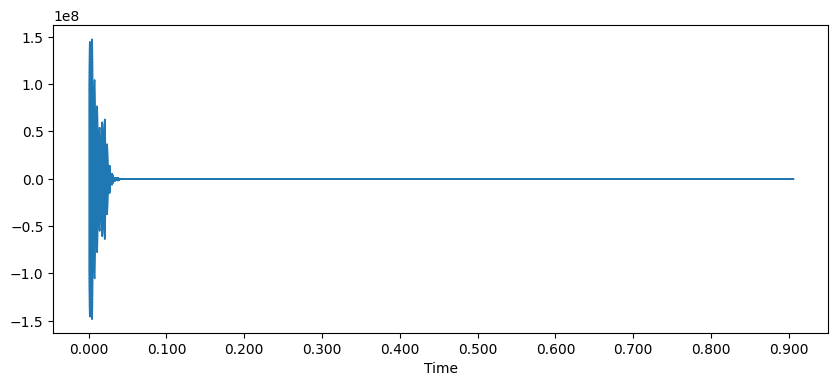

In [33]:
# Visualize the Image and Label Batches from TensorFlow Dataset

for audio_batch, label_batch in train_ds.take(1):
    print(audio_batch.numpy()[0].shape)
    print(audio_batch.numpy()[0])
    print()

    print(label_batch.numpy().shape)
    print(label_batch.numpy()[0])
    print()

    audio = librosa.feature.inverse.mfcc_to_audio(audio_batch.numpy())

    # Plot the reconstructed audio waveform
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(audio)
    plt.show()

In [34]:
# Overview of Training Dataset Structure and Specifications
train_ds

<_TakeDataset element_spec=(TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [35]:
# Building an Optimized Data Pipeline for Enhanced Performance

# Training Dataset
train_ds = train_ds.cache().shuffle(buffer_size=1000).prefetch(tf.data.AUTOTUNE)

# Validation Dataset
validation_ds = validation_ds.cache().shuffle(buffer_size=1000).prefetch(tf.data.AUTOTUNE)

# Testing Dataset
test_ds = test_ds.cache().shuffle(buffer_size=1000).prefetch(tf.data.AUTOTUNE)

### **Model Building & Training**

In [36]:
# Define the Parameters of Input_shape, Channel and Target

mfcc_features = 40    # Extracted features from Audio
channel = 1           # Mono Channel
target = 114          # Output Classes

input_shape = (mfcc_features, channel)
print(f'Input Shape: {input_shape}')

Input Shape: (40, 1)


In [37]:
# Build a CNN Model Architecture

model = keras.Sequential([

            # Input Layer
            keras.layers.Input(shape=input_shape),

            # 1st Conv Layer
            keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
            keras.layers.BatchNormalization(),
            keras.layers.MaxPool1D(pool_size=2, padding='same'),

            # 2nd Conv Layer
            keras.layers.Conv1D(filters=256, kernel_size=3, activation='relu'),
            keras.layers.BatchNormalization(),
            keras.layers.MaxPool1D(pool_size=2, padding='same'),

            # 3rd Conv Layer
            keras.layers.Conv1D(filters=256, kernel_size=3, activation='relu'),
            keras.layers.BatchNormalization(),
            keras.layers.MaxPool1D(pool_size=2, padding='same'),

            # Flatten and Convert into 1-Dimentional Vector
            keras.layers.Flatten(),

            # 1st Fully Connected Dense Layer
            keras.layers.Dense(units=512, activation='relu', kernel_regularizer=keras.regularizers.L2(l2=1e-3)),
            keras.layers.Dropout(rate=0.3),

            # 2nd Fully Connected Dense Layer
            keras.layers.Dense(units=512, activation='relu', kernel_regularizer=keras.regularizers.L2(l2=1e-3)),
            keras.layers.Dropout(rate=0.3),

            # Output Layer
            keras.layers.Dense(units=target, activation='softmax')
        ])

model

<Sequential name=sequential, built=True>

In [38]:
# Display the Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 9, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 114)            │        58,482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,434 (4.37 MB)

 Trainable params: 1,143,154 (4.36 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [39]:
# Installing visualkeras
!pip install -q visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 25.0 MB/s eta 0:00:00


--2025-05-03 13:42:18--  https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/matomo-org/travis-scripts/master/fonts/Arial.ttf [following]
--2025-05-03 13:42:19--  https://raw.githubusercontent.com/matomo-org/travis-scripts/master/fonts/Arial.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 275572 (269K) [application/octet-stream]
Saving to: ‘arial.ttf’

arial.ttf           100%[===================>] 269.11K  --.-KB/s    in 0.02s   

2025-05-03 13:42:19 (10.6 MB/s) - ‘arial.ttf’ saved [275572/275572]



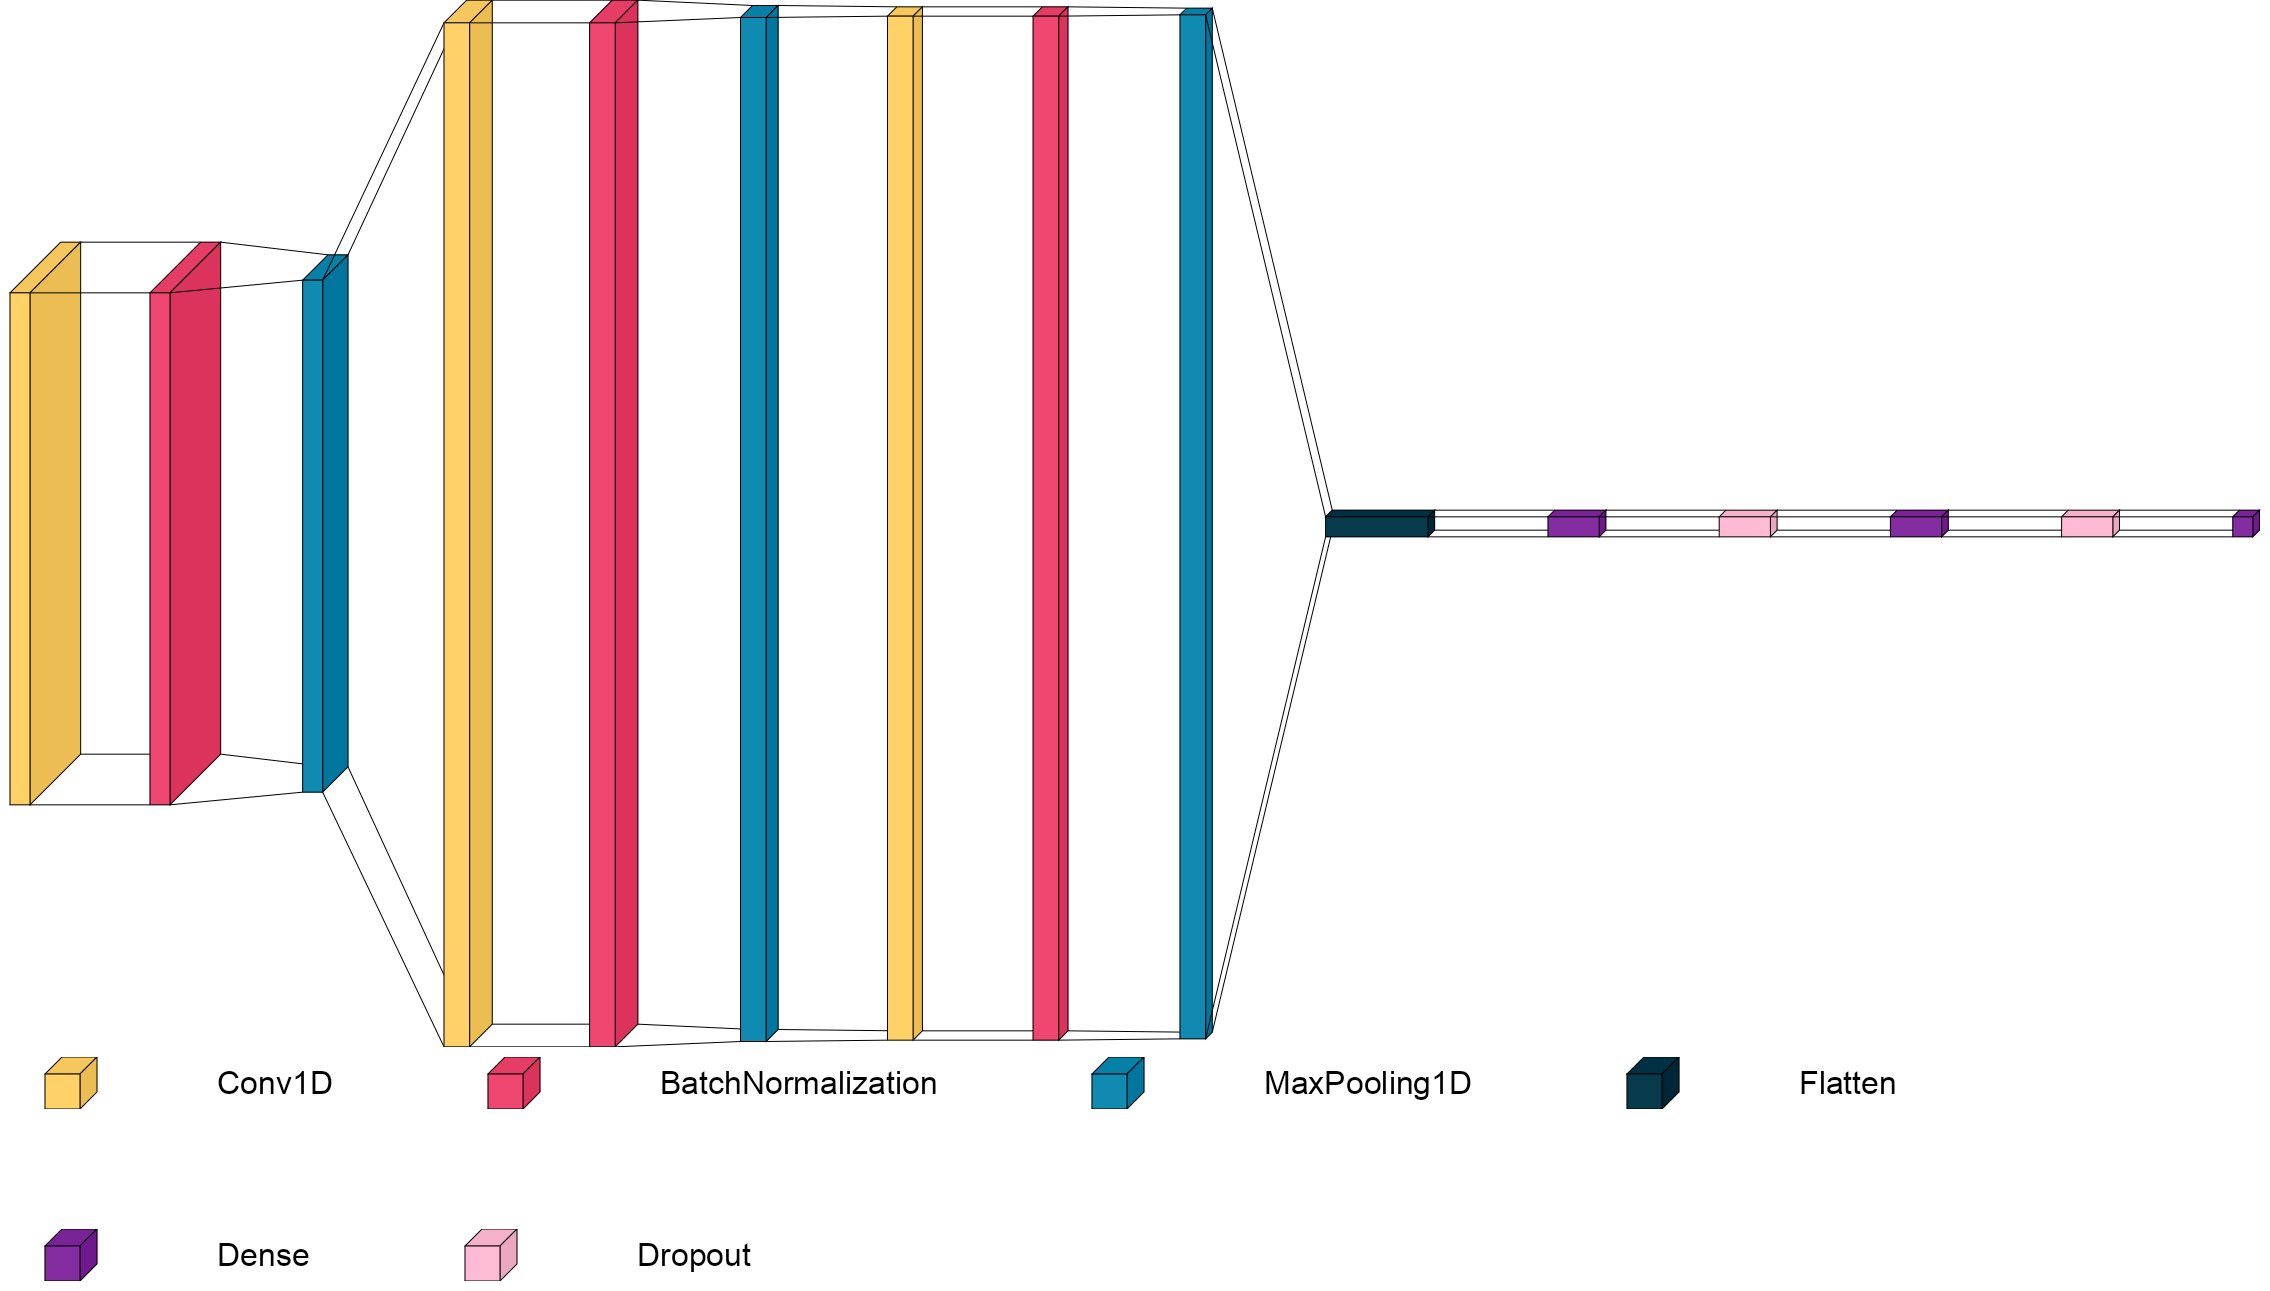

In [40]:
import visualkeras
from PIL import ImageFont
import os

# Download a font file directly in Colab
!wget -O arial.ttf https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf

# Use the downloaded font with a very large size
font = ImageFont.truetype("arial.ttf", 32)  # Very large font size

# Create the visualization with larger components
visualkeras.layered_view(model,
                        to_file='model_viz.png',
                        font=font,
                        spacing=120,
                        legend=True)

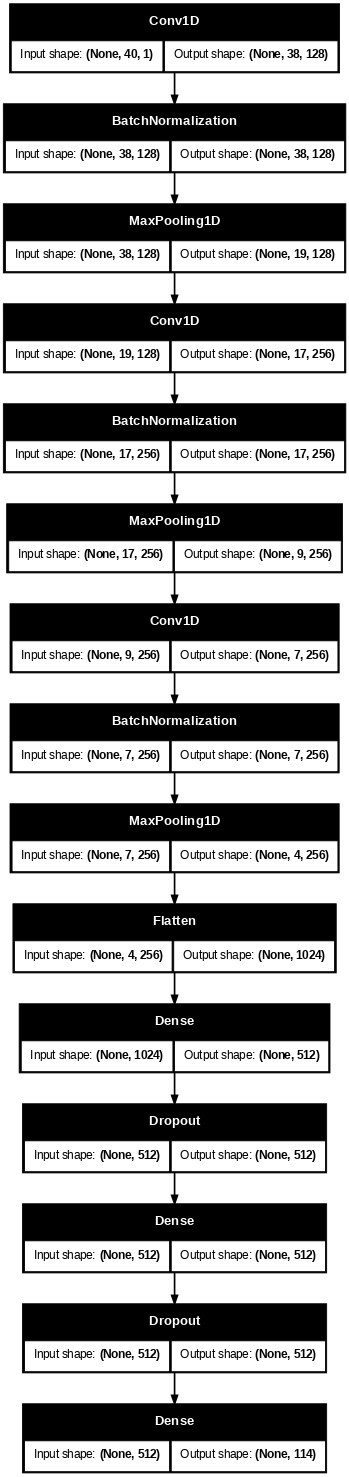

In [41]:
# Visualize the model
keras.utils.plot_model(model, expand_nested=True, dpi=60, show_shapes=True)

In [42]:
# Compiling the Model with Optimizer, Loss, and Metrics

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model

<Sequential name=sequential, built=True>

In [43]:
# Model Training with Training_Dataset and Evaluated with Validation_Dataset

history = model.fit(train_ds,
                    batch_size=batch_size,
                    epochs=700,
                    verbose=1,
                    validation_data = validation_ds)
history

Epoch 1/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 186ms/step - accuracy: 0.0051 - loss: 6.7350 - val_accuracy: 0.0113 - val_loss: 6.0502
Epoch 2/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0103 - loss: 6.5537 - val_accuracy: 0.0000e+00 - val_loss: 5.9892
Epoch 3/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0168 - loss: 6.3505 - val_accuracy: 0.0056 - val_loss: 5.9619
Epoch 4/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0185 - loss: 6.1760 - val_accuracy: 0.0113 - val_loss: 5.9196
Epoch 5/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0240 - loss: 6.0909 - val_accuracy: 0.0113 - val_loss: 5.8704
Epoch 6/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0505 - loss: 5.8219 - val_accuracy: 0.0169 - val_loss: 5.8375
Epoch 7/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0313 - loss: 5.8854 - val_accuracy: 0.0395 - val_loss: 5.7736
Epoch 8/700
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0313 - loss: 5.8199 - val_accuracy: 0.1

In [44]:
# Evaluating Model Performance on Test Dataset
model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9317 - loss: 0.8459 


[1.0806190967559814, 0.87890625]

In [45]:
# Accessing Training History Parameters
history.params

{'verbose': 1, 'epochs': 700, 'steps': 54}

In [46]:
# Accessing Keys of Training History
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [47]:
# Extracting Accuracy Metrics from Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Extracting Loss Metrics from Training History
loss = history.history['loss']
val_loss = history.history['val_loss']

In [48]:
len(acc), len(val_acc), len(loss), len(val_loss)

(700, 700, 700, 700)

In [49]:
# Save the Model
model.save(f'{bird_path}/model.h5')

Text(0.5, 1.0, 'Training vs Validation Loss')

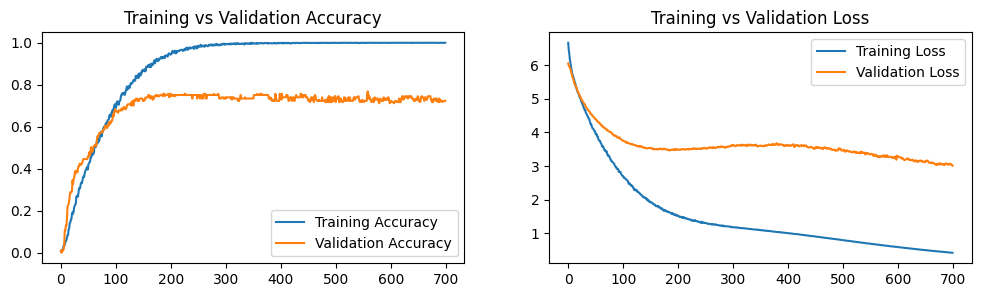

In [50]:
# Visualize the Acuuracy & Loss using Plots

plt.figure(figsize=(12, 3))

plt.subplot(1, 2, 1)
plt.plot(range(len(acc)), acc, label='Training Accuracy')
plt.plot(range(len(val_acc)), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(len(loss)), loss, label='Training Loss')
plt.plot(range(len(val_loss)), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')

In [51]:
# Load your prediction dictionary (mapping from class indices to bird names)
with open(f'{bird_path}/prediction.json', mode='r') as f:
    prediction_dict = json.load(f)

class_names = [prediction_dict[str(i)] for i in range(len(prediction_dict))]

# Function to get predictions and true labels from your test dataset
def get_predictions_and_labels(model, test_ds):
    # Lists to store predictions and true labels
    y_pred_list = []
    y_true_list = []

    # Iterate through test dataset
    for x, y in test_ds:
        # Get predictions
        predictions = model.predict(x, verbose=0)
        pred_labels = np.argmax(predictions, axis=1)

        # Get true labels (assuming they're already one-hot encoded in your dataset)
        true_labels = np.argmax(y.numpy(), axis=1) if len(y.shape) > 1 else y.numpy()

        # Append to lists
        y_pred_list.append(pred_labels)
        y_true_list.append(true_labels)

    # Concatenate batch results
    y_pred = np.concatenate(y_pred_list)
    y_true = np.concatenate(y_true_list)

    return y_pred, y_true

In [52]:
y_pred, y_true = get_predictions_and_labels(model, test_ds)

In [53]:
# Find unique classes in your prediction data
unique_classes = np.unique(np.concatenate([y_true, y_pred]))
# Filter class_names to only include classes present in your data
used_class_names = [class_names[i] for i in unique_classes]

In [54]:
# Modified function to handle class mismatch
def plot_confusion_matrix(y_true, y_pred, all_class_names):
    # Find unique classes in your prediction data
    unique_classes = np.unique(np.concatenate([y_true, y_pred]))

    # Filter class_names to only include classes present in your data
    used_class_names = [all_class_names[i] for i in unique_classes]

    # Calculate confusion matrix for only the classes in your data
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=used_class_names, yticklabels=used_class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300)
    plt.show()

    # Calculate and display accuracy
    accuracy = np.sum(np.diag(cm)) / np.sum(cm)
    print(f'Overall Accuracy: {accuracy * 100:.2f}%')


    # Print classification report with just the classes present in your data
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, labels=unique_classes,
                              target_names=all_class_names))

    # Print information about class distribution
    print(f"\nTest data contains {len(np.unique(y_true))} unique true classes")
    print(f"Model predicted {len(np.unique(y_pred))} unique classes")

In [55]:
print(f"Number of unique classes in true labels: {len(np.unique(y_true))}")
print(f"Number of unique classes in predicted labels: {len(np.unique(y_pred))}")
print(f"Number of entries in prediction_dict: {len(prediction_dict)}")
print(f"First few class names: {class_names[:5]}")

Number of unique classes in true labels: 21
Number of unique classes in predicted labels: 29
Number of entries in prediction_dict: 114
First few class names: ['Andean Guan_sound', 'Andean Tinamou_sound', 'Australian Brushturkey_sound', 'Band-tailed Guan_sound', 'Barred Tinamou_sound']


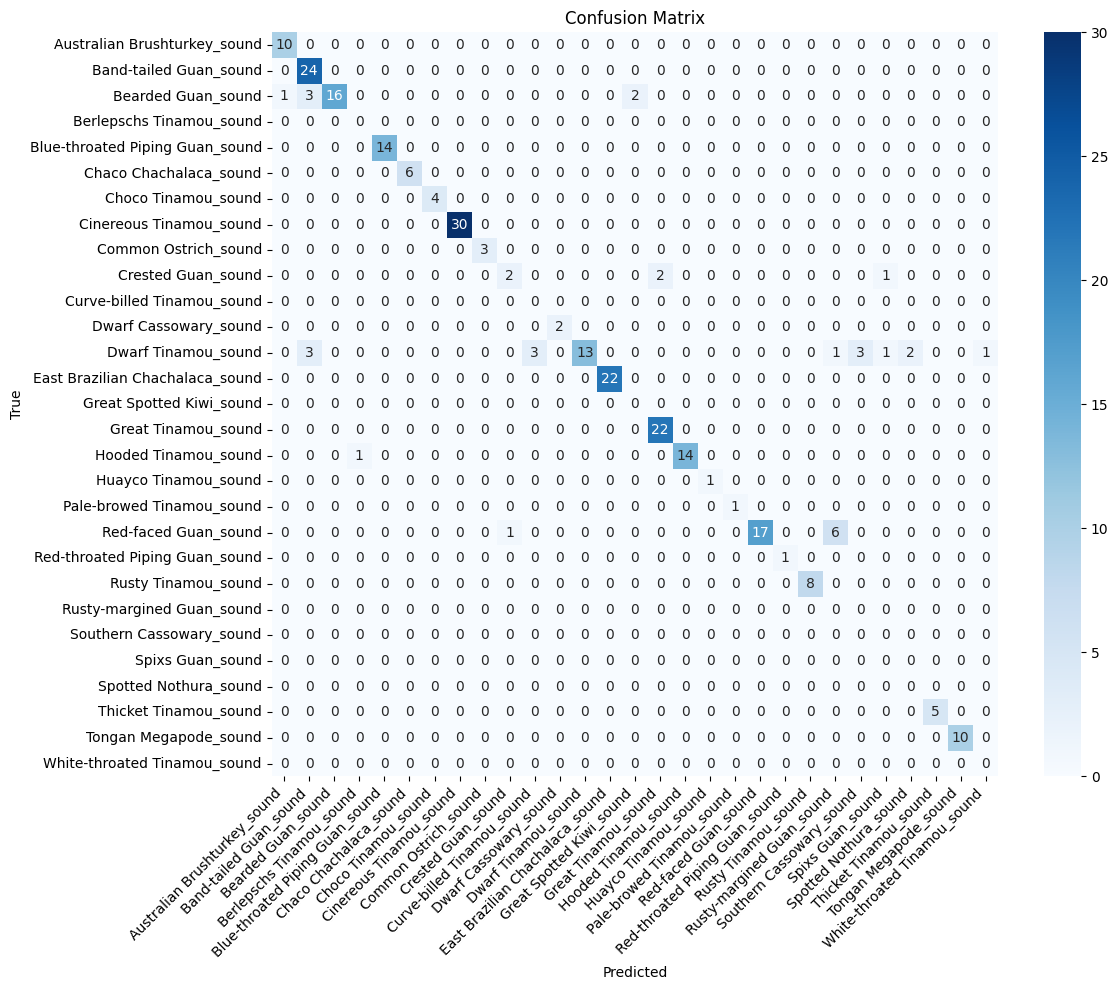

Overall Accuracy: 87.89%

Classification Report:
                                  precision    recall  f1-score   support

               Andean Guan_sound       0.91      1.00      0.95        10
            Andean Tinamou_sound       0.80      1.00      0.89        24
    Australian Brushturkey_sound       1.00      0.73      0.84        22
          Band-tailed Guan_sound       0.00      0.00      0.00         0
            Barred Tinamou_sound       1.00      1.00      1.00        14
         Bartletts Tinamou_sound       1.00      1.00      1.00         6
                Baudo Guan_sound       1.00      1.00      1.00         4
              Bearded Guan_sound       1.00      1.00      1.00        30
        Berlepschs Tinamou_sound       1.00      1.00      1.00         3
            Biak Scrubfowl_sound       0.67      0.40      0.50         5
             Black Tinamou_sound       0.00      0.00      0.00         0
  Black-billed Brushturkey_sound       1.00      1.00      1.0

In [56]:
# Plot confusion matrix
plot_confusion_matrix(y_true, y_pred, class_names)

### **Model Inference**

In [57]:
def prediction(audio_file):

    # Load the Prediction JSON File to Predict Target_Label
    with open(f'{bird_path}/prediction.json', mode='r') as f:
        prediction_dict = json.load(f)

    # Extract the Audio_Signal and Sample_Rate from Input Audio
    audio, sample_rate =librosa.load(audio_file)

    # Extract the MFCC Features and Aggrigate
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_features = np.mean(mfccs_features, axis=1)

    # Reshape MFCC features to match the expected input shape for Conv1D both batch & feature dimension
    mfccs_features = np.expand_dims(mfccs_features, axis=0)
    mfccs_features = np.expand_dims(mfccs_features, axis=2)

    # Convert into Tensors
    mfccs_tensors = tf.convert_to_tensor(mfccs_features, dtype=tf.float32)

    # Load the Model and Prediction
    model = tf.keras.models.load_model(f'{bird_path}/model.h5')
    prediction = model.predict(mfccs_tensors)

    # Find the Maximum Probability Value
    target_label = np.argmax(prediction)

    # Find the Target_Label Name using Prediction_dict
    predicted_class = prediction_dict[str(target_label)]
    confidence = round(np.max(prediction)*100, 2)

    print(f'Predicted Class : {predicted_class}')
    print(f'Confidence : {confidence}%')

In [58]:
import os

# Navigate to the inner Voice of Birds directory
inner_voice_path = os.path.join(bird_path, 'Voice of Birds', 'Voice of Birds')

if os.path.exists(inner_voice_path):
    print(f"Contents of inner 'Voice of Birds' folder:")
    inner_files = os.listdir(inner_voice_path)
    print(f"Total items: {len(inner_files)}")

    # Show first few items to get an idea
    if len(inner_files) > 0:
        print("First 10 items (or all if fewer):")
        for file in inner_files[:]:
            print(f"  - {file}")

        # If there are many files, they're likely organized by bird species
        # Let's check if they're directories
        first_item = os.path.join(inner_voice_path, inner_files[0])
        if os.path.isdir(first_item):
            print(f"\nThe first item ({inner_files[0]}) is a directory. Contents:")
            print(os.listdir(first_item)[:5])  # Show first 5 items
else:
    print(f"Directory '{inner_voice_path}' does not exist")

Contents of inner 'Voice of Birds' folder:
Total items: 114
First 10 items (or all if fewer):
  - Southern Brown Kiwi_sound
  - Black-capped Tinamou_sound
  - Brown Tinamou_sound
  - Rufous-bellied Chachalaca_sound
  - White-throated Tinamou_sound
  - Colombian Chachalaca_sound
  - Orange-footed Scrubfowl_sound
  - Trinidad Piping Guan_sound
  - Little Spotted Kiwi_sound
  - White-winged Guan_sound
  - Barred Tinamou_sound
  - Lesser Rhea_sound
  - Brazilian Tinamou_sound
  - Huayco Tinamou_sound
  - Cinereous Tinamou_sound
  - Pale-browed Tinamou_sound
  - Andean Guan_sound
  - Bearded Guan_sound
  - Tongan Megapode_sound
  - Quebracho Crested Tinamou_sound
  - Buff-browed Chachalaca_sound
  - Red-legged Tinamou_sound
  - Curve-billed Tinamou_sound
  - Solitary Tinamou_sound
  - Patagonian Tinamou_sound
  - Choco Tinamou_sound
  - East Brazilian Chachalaca_sound
  - Chaco Chachalaca_sound
  - Chestnut-winged Chachalaca_sound
  - Somali Ostrich_sound
  - Little Tinamou_sound
  - Cauca 

In [59]:
prediction(f'{bird_path}/Voice of Birds/Voice of Birds/Andean Guan_sound/Andean Guan3.mp3')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step
Predicted Class : Andean Guan_sound
Confidence : 94.44000244140625%


In [60]:
prediction(f'{bird_path}/Voice of Birds/Voice of Birds/Buff-browed Chachalaca_sound/Buff-browed Chachalaca2.mp3')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step
Predicted Class : Chestnut-headed Chachalaca_sound
Confidence : 65.52999877929688%
